In [1]:
import json
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from predict_knowledge_driven_model import predict_power_knowledge_model
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.lines as mlines

In [2]:
entsoe_timeseries_df = pd.read_csv("../datasets/entsoe.csv", index_col=0, parse_dates=True)
with open("../metadata_wind_farms.json") as f:
    wind_farms_metadata = json.load(f)["wind_farms"]

In [3]:
wind_farm_id_list = [wf["id"] for wf in wind_farms_metadata if wf.get("offshore_data_available") is True]
print(wind_farm_id_list)

['Borssele_12', 'Borssele_34', 'Gemini', 'Hollandse_Kust_Zuid', 'Hollandse_Kust_Noord']


In [4]:
df_nearest_KNMI_stations = {}
for wind_farm in wind_farms_metadata:
    station = wind_farm.get("nearest_KNMI_station")
    try:
        df = pd.read_csv("../datasets/knmi_"+station+".csv",  index_col=0, parse_dates=True)
        df_nearest_KNMI_stations[wind_farm['id']] = df
    except:
        print(f"No file found for station {station} needed for {wind_farm['id']}")

No file found for station None needed for Windfarm_Princess_Amalia
No file found for station None needed for OWEZ


In [5]:
df_nearest_KNMI_stations["Gemini"]["wind_speed_ms"]

timestamp
2015-01-01 00:00:00    8.0
2015-01-01 01:00:00    8.0
2015-01-01 02:00:00    9.0
2015-01-01 03:00:00    9.0
2015-01-01 04:00:00    9.0
                      ... 
2026-06-01 19:00:00    7.0
2026-06-01 20:00:00    7.0
2026-06-01 21:00:00    7.0
2026-06-01 22:00:00    7.0
2026-06-01 23:00:00    8.0
Name: wind_speed_ms, Length: 100080, dtype: float64

In [6]:
df_borssele_12 = pd.read_csv("../datasets/offshore_Borssele_12.csv", index_col="time", parse_dates=True)
df_borssele_34 = pd.read_csv("../datasets/offshore_Borssele_34.csv", index_col="time", parse_dates=True)
df_gemini = pd.read_csv("../datasets/offshore_Gemini.csv", index_col="time", parse_dates=True)
df_h_k_zuid = pd.read_csv("../datasets/offshore_Hollandse_Kust_Zuid.csv", index_col="time", parse_dates=True)
df_h_k_noord = pd.read_csv("../datasets/offshore_Hollandse_Kust_Noord.csv", index_col="time", parse_dates=True)

datasets = {
    'Borssele_12': df_borssele_12,
    'Borssele_34': df_borssele_34,
    'Gemini':       df_gemini,
    'Hollandse_Kust_Zuid': df_h_k_zuid,
    'Hollandse_Kust_Noord': df_h_k_noord,
}

In [7]:
linear_fits = {}

for farm_name, farm_df in datasets.items():
    knmi_df = df_nearest_KNMI_stations[farm_name]

    # merge on shared timestamps (inner join keeps only overlapping hours)
    merged = farm_df[['Windspeed']].join(
        knmi_df[['wind_speed_ms']],
        how='inner'
    ).dropna()

    X = merged[['wind_speed_ms']].values  # KNMI windspeed (predictor)
    y = merged['Windspeed'].values  # farm windspeed (target)

    model = LinearRegression()
    model.fit(X, y)

    slope = model.coef_[0]
    intercept = model.intercept_
    r2 = model.score(X, y)

    linear_fits[farm_name] = {
        "slope": slope,
        "intercept": intercept,
        "r2": r2,
        "n_points": len(merged),
    }

    print(f"{farm_name}: farm_ws = {slope:.4f} * knmi_ws + {intercept:.4f}  (R²={r2:.3f}, n={len(merged)})")

Borssele_12: farm_ws = 1.1400 * knmi_ws + 2.1281  (R²=0.710, n=43824)
Borssele_34: farm_ws = 1.0894 * knmi_ws + 2.5045  (R²=0.657, n=43824)
Gemini: farm_ws = 1.1969 * knmi_ws + 2.2181  (R²=0.691, n=43824)
Hollandse_Kust_Zuid: farm_ws = 1.1088 * knmi_ws + 1.0726  (R²=0.727, n=43824)
Hollandse_Kust_Noord: farm_ws = 1.0749 * knmi_ws + 1.6631  (R²=0.638, n=43824)


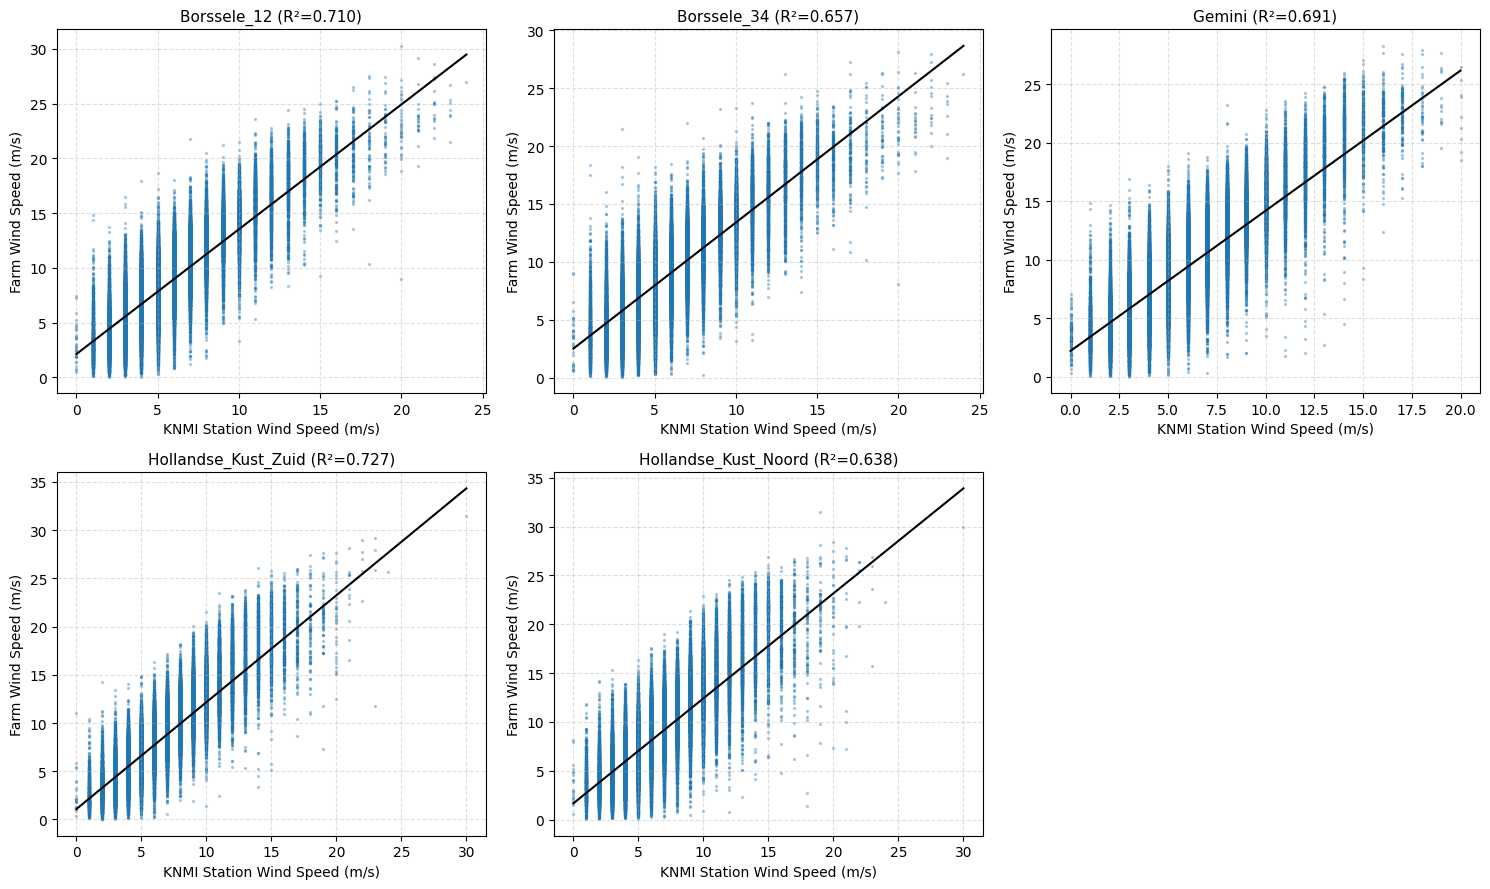

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (farm_name, farm_df) in enumerate(datasets.items()):
    knmi_df = df_nearest_KNMI_stations[farm_name]

    merged = farm_df[['Scaled_Windspeed']].join(
        knmi_df[['wind_speed_ms']],
        how='inner'
    ).dropna()

    x = merged['wind_speed_ms'].values
    y = merged['Scaled_Windspeed'].values

    fit = linear_fits[farm_name]
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = fit["slope"] * x_line + fit["intercept"]

    ax = axes[i]
    ax.scatter(x, y, alpha=0.3, s=2, color='tab:blue')
    ax.plot(x_line, y_line, color='black', linewidth=1.5)
    ax.set_title(f"{farm_name} (R²={fit['r2']:.3f})", fontsize=11)
    ax.set_xlabel('KNMI Station Wind Speed (m/s)')
    ax.set_ylabel('Farm Wind Speed (m/s)')
    ax.grid(True, linestyle='--', alpha=0.4)

# hide the unused 6th subplot (5 farms, 2x3 grid)
axes[-1].axis('off')

plt.tight_layout()
plt.show()

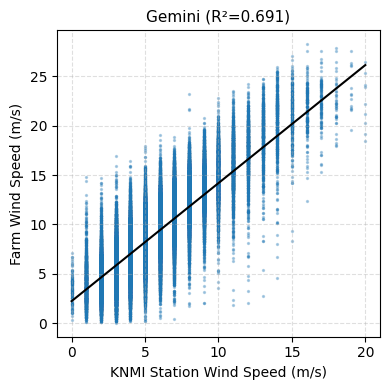

In [9]:
fig, axes = plt.subplots(1, 1, figsize=(4, 4))

#for i, (farm_name, farm_df) in enumerate(datasets.items()):

farm_name = "Gemini"

knmi_df = df_nearest_KNMI_stations[farm_name]

merged = datasets[farm_name][['Scaled_Windspeed']].join(
    knmi_df[['wind_speed_ms']],
    how='inner'
).dropna()

x = merged['wind_speed_ms'].values
y = merged['Scaled_Windspeed'].values

fit = linear_fits[farm_name]
x_line = np.linspace(x.min(), x.max(), 100)
y_line = fit["slope"] * x_line + fit["intercept"]

ax = axes
ax.scatter(x, y, alpha=0.3, s=2, color='tab:blue')
ax.plot(x_line, y_line, color='black', linewidth=1.5)
ax.set_title(f"{farm_name} (R²={fit['r2']:.3f})", fontsize=11)
ax.set_xlabel('KNMI Station Wind Speed (m/s)')
ax.set_ylabel('Farm Wind Speed (m/s)')
ax.grid(True, linestyle='--', alpha=0.4)


plt.tight_layout()
plt.show()

C:\Users\lackn\AppData\Local\Temp\ipykernel_28720\865983651.py:11: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


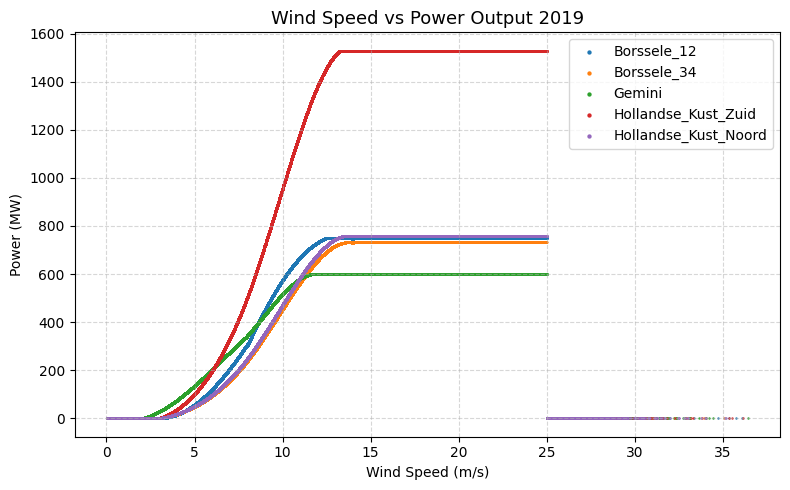

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

for label, df in datasets.items():
    ax.scatter(df['Scaled_Windspeed'], df['Power'], alpha=1, s=0.5, label=label)

ax.set_title('Wind Speed vs Power Output 2019', fontsize=13)
ax.set_xlabel('Wind Speed (m/s)')
ax.set_ylabel('Power (MW)')
ax.legend(markerscale=3)   # markerscale makes the tiny dots visible in the legend
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [12]:
def logistic_piece(v, alpha, beta, gamma, delta):
    return alpha / (1 + np.exp(-gamma * (v - delta))) ** (1 / beta)

def double_logistic(v, alpha1, beta1, gamma1, delta1, alpha2, beta2, gamma2, delta2):
    return (logistic_piece(v, alpha1, beta1, gamma1, delta1) +
            logistic_piece(v, alpha2, beta2, gamma2, delta2))

In [13]:
results = []

Fitted parameters:
alpha1=217.722, beta1=0.169, gamma1=0.731, delta1=3.511
alpha2=535.733, beta2=1.406, gamma2=1.084, delta2=9.621


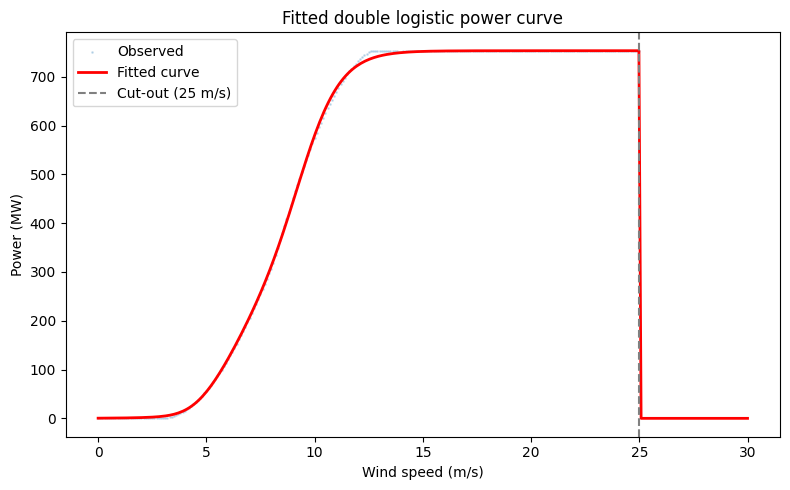

In [14]:
df = df_borssele_12

fit_df = df[(df["Turn_off"] == 1) & (df["Scaled_Windspeed"] > 0)].copy()

fit_df["v_bin"] = fit_df["Scaled_Windspeed"].round(1)
binned = fit_df.groupby("v_bin")["Power"].mean().reset_index()

v = binned["v_bin"].values
p = binned["Power"].values

p0 = [
    400, 1.0, 0.5, 6.0,
    330, 1.0, 0.5, 11.0
]

popt, pcov = curve_fit(double_logistic, v, p, p0=p0, bounds=(
    [0, 0.01, 0, 0, 0, 0.01, 0, 0],
    [np.inf, 10, 10, 30, np.inf, 10, 10, 30]
), method='dogbox', maxfev=20000)

print("Fitted parameters:")
print(f"alpha1={popt[0]:.3f}, beta1={popt[1]:.3f}, gamma1={popt[2]:.3f}, delta1={popt[3]:.3f}")
print(f"alpha2={popt[4]:.3f}, beta2={popt[5]:.3f}, gamma2={popt[6]:.3f}, delta2={popt[7]:.3f}")

results.append({
    'windfarm':   "Borssele_12",
    'alpha1': popt[0], 'beta1': popt[1],
    'gamma1': popt[2], 'delta1': popt[3],
    'alpha2': popt[4], 'beta2': popt[5],
    'gamma2': popt[6], 'delta2': popt[7],
})

# --- apply cut-out at 25 m/s ---
v_range = np.linspace(0, 30, 300)
p_fitted = np.where(
    v_range <= 25,
    double_logistic(v_range, *popt),
    0
)

# --- plot ---
plt.figure(figsize=(8, 5))
plt.scatter(v, p, s=1, alpha=0.2, label="Observed")
plt.plot(v_range, p_fitted, color="red", linewidth=2, label="Fitted curve")
plt.axvline(25, color="gray", linestyle="--", label="Cut-out (25 m/s)")
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Power (MW)")
plt.title("Fitted double logistic power curve")
plt.legend()
plt.tight_layout()
plt.show()

Fitted parameters:
alpha1=326.769, beta1=0.742, gamma1=0.719, delta1=7.032
alpha2=405.992, beta2=2.492, gamma2=1.429, delta2=11.462


C:\Users\lackn\AppData\Local\Temp\ipykernel_28720\784927076.py:2: RuntimeWarning: overflow encountered in power
  return alpha / (1 + np.exp(-gamma * (v - delta))) ** (1 / beta)


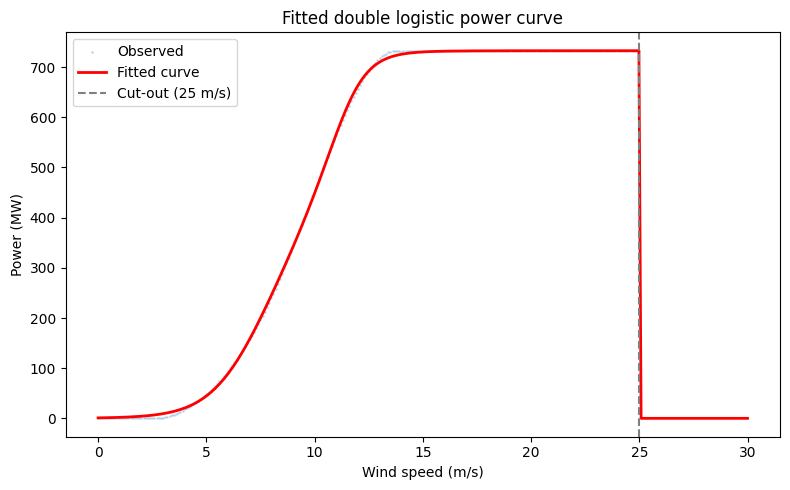

In [15]:
df = df_borssele_34

fit_df = df[(df["Turn_off"] == 1) & (df["Scaled_Windspeed"] > 0)].copy()

fit_df["v_bin"] = fit_df["Scaled_Windspeed"].round(1)
binned = fit_df.groupby("v_bin")["Power"].mean().reset_index()

v = binned["v_bin"].values
p = binned["Power"].values

p0 = [
    400, 1.0, 0.5, 6.0,
    330, 1.0, 0.5, 11.0
]

popt, pcov = curve_fit(double_logistic, v, p, p0=p0, bounds=([0, 0.01, 0, 0, 0, 0.01, 0, 0], [np.inf, 10, 10, 30, np.inf, 10, 10, 30]), method='dogbox')

print("Fitted parameters:")
print(f"alpha1={popt[0]:.3f}, beta1={popt[1]:.3f}, gamma1={popt[2]:.3f}, delta1={popt[3]:.3f}")
print(f"alpha2={popt[4]:.3f}, beta2={popt[5]:.3f}, gamma2={popt[6]:.3f}, delta2={popt[7]:.3f}")

results.append({
    'windfarm':   "Borssele_34",
    'alpha1': popt[0], 'beta1': popt[1],
    'gamma1': popt[2], 'delta1': popt[3],
    'alpha2': popt[4], 'beta2': popt[5],
    'gamma2': popt[6], 'delta2': popt[7],
})

# --- apply cut-out at 25 m/s ---
v_range = np.linspace(0, 30, 300)
p_fitted = np.where(
    v_range <= 25,
    double_logistic(v_range, *popt),
    0
)

# --- plot ---
plt.figure(figsize=(8, 5))
plt.scatter(v, p, s=1, alpha=0.2, label="Observed")
plt.plot(v_range, p_fitted, color="red", linewidth=2, label="Fitted curve")
plt.axvline(25, color="gray", linestyle="--", label="Cut-out (25 m/s)")
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Power (MW)")
plt.title("Fitted double logistic power curve")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\lackn\AppData\Local\Temp\ipykernel_28720\784927076.py:2: RuntimeWarning: overflow encountered in power
  return alpha / (1 + np.exp(-gamma * (v - delta))) ** (1 / beta)


Fitted parameters:
alpha1=603.831, beta1=1.359, gamma1=0.712, delta1=7.971
alpha2=0.000, beta2=0.010, gamma2=1.881, delta2=12.574


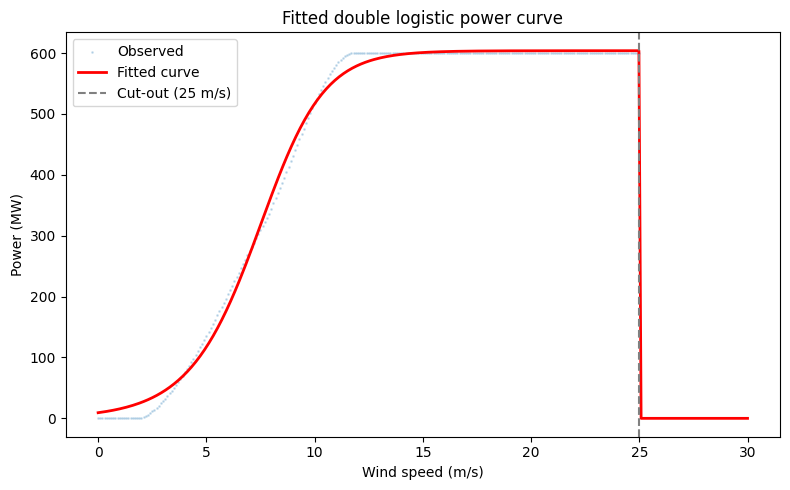

In [16]:
df = df_gemini

fit_df = df[(df["Turn_off"] == 1) & (df["Scaled_Windspeed"] > 0)].copy()

fit_df["v_bin"] = fit_df["Scaled_Windspeed"].round(1)
binned = fit_df.groupby("v_bin")["Power"].mean().reset_index()

v = binned["v_bin"].values
p = binned["Power"].values

p0 = [
    p.max(), 1.0, 0.7, 8.0,
    p.max(), 2.5, 1.4, 11.0
]

popt, pcov = curve_fit(
    double_logistic,
    v, p,
    p0=p0,
    bounds=(
        [0, 0.01, 0, 0, 0, 0.01, 0, 0],
        [np.inf, 10, 10, 30, np.inf, 10, 10, 30]
    ),
    method='dogbox',
    maxfev=20000
)

print("Fitted parameters:")
print(f"alpha1={popt[0]:.3f}, beta1={popt[1]:.3f}, gamma1={popt[2]:.3f}, delta1={popt[3]:.3f}")
print(f"alpha2={popt[4]:.3f}, beta2={popt[5]:.3f}, gamma2={popt[6]:.3f}, delta2={popt[7]:.3f}")

results.append({
    'windfarm':   "Gemini",
    'alpha1': popt[0], 'beta1': popt[1],
    'gamma1': popt[2], 'delta1': popt[3],
    'alpha2': popt[4], 'beta2': popt[5],
    'gamma2': popt[6], 'delta2': popt[7],
})

# --- apply cut-out at 25 m/s ---
v_range = np.linspace(0, 30, 300)
p_fitted = np.where(
    v_range <= 25,
    double_logistic(v_range, *popt),
    0
)

# --- plot ---
plt.figure(figsize=(8, 5))
plt.scatter(v, p, s=1, alpha=0.2, label="Observed")
plt.plot(v_range, p_fitted, color="red", linewidth=2, label="Fitted curve")
plt.axvline(25, color="gray", linestyle="--", label="Cut-out (25 m/s)")
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Power (MW)")
plt.title("Fitted double logistic power curve")
plt.legend()
plt.tight_layout()
plt.show()

Fitted parameters:
alpha1=338.947, beta1=0.742, gamma1=0.718, delta1=7.029
alpha2=421.362, beta2=2.492, gamma2=1.429, delta2=11.462


C:\Users\lackn\AppData\Local\Temp\ipykernel_28720\784927076.py:2: RuntimeWarning: overflow encountered in power
  return alpha / (1 + np.exp(-gamma * (v - delta))) ** (1 / beta)


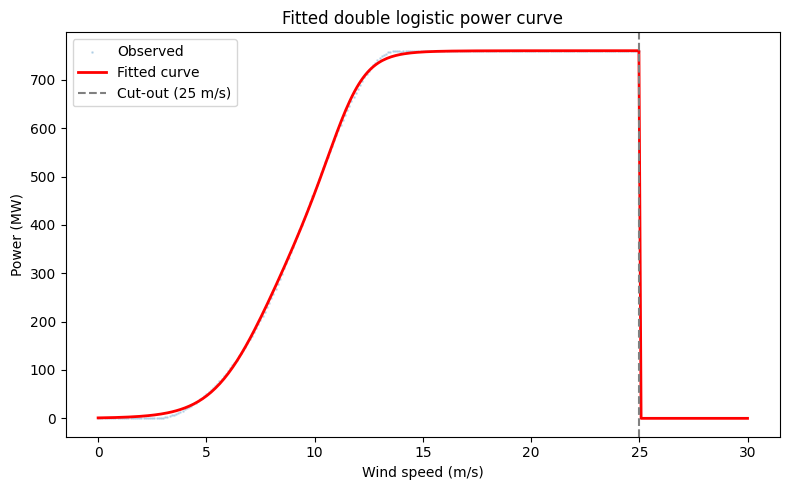

In [17]:
df = df_h_k_noord

fit_df = df[(df["Turn_off"] == 1) & (df["Scaled_Windspeed"] > 0)].copy()

fit_df["v_bin"] = fit_df["Scaled_Windspeed"].round(1)
binned = fit_df.groupby("v_bin")["Power"].mean().reset_index()

v = binned["v_bin"].values
p = binned["Power"].values

p0 = [
    400, 1.0, 0.5, 6.0,
    330, 1.0, 0.5, 11.0
]

popt, pcov = curve_fit(
    double_logistic,
    v, p,
    p0=p0,
    bounds=(
        [0, 0.01, 0, 0, 0, 0.01, 0, 0],
        [np.inf, 10, 10, 30, np.inf, 10, 10, 30]
    ),
    method='dogbox',
    maxfev=20000
)

print("Fitted parameters:")
print(f"alpha1={popt[0]:.3f}, beta1={popt[1]:.3f}, gamma1={popt[2]:.3f}, delta1={popt[3]:.3f}")
print(f"alpha2={popt[4]:.3f}, beta2={popt[5]:.3f}, gamma2={popt[6]:.3f}, delta2={popt[7]:.3f}")

results.append({
    'windfarm':   "Hollandse_Kust_Noord",
    'alpha1': popt[0], 'beta1': popt[1],
    'gamma1': popt[2], 'delta1': popt[3],
    'alpha2': popt[4], 'beta2': popt[5],
    'gamma2': popt[6], 'delta2': popt[7],
})

# --- apply cut-out at 25 m/s ---
v_range = np.linspace(0, 30, 300)
p_fitted = np.where(
    v_range <= 25,
    double_logistic(v_range, *popt),
    0
)

# --- plot ---
plt.figure(figsize=(8, 5))
plt.scatter(v, p, s=1, alpha=0.2, label="Observed")
plt.plot(v_range, p_fitted, color="red", linewidth=2, label="Fitted curve")
plt.axvline(25, color="gray", linestyle="--", label="Cut-out (25 m/s)")
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Power (MW)")
plt.title("Fitted double logistic power curve")
plt.legend()
plt.tight_layout()
plt.show()

Fitted parameters:
alpha1=691.469, beta1=0.775, gamma1=0.732, delta1=7.125
alpha2=840.127, beta2=2.675, gamma2=1.519, delta2=11.489


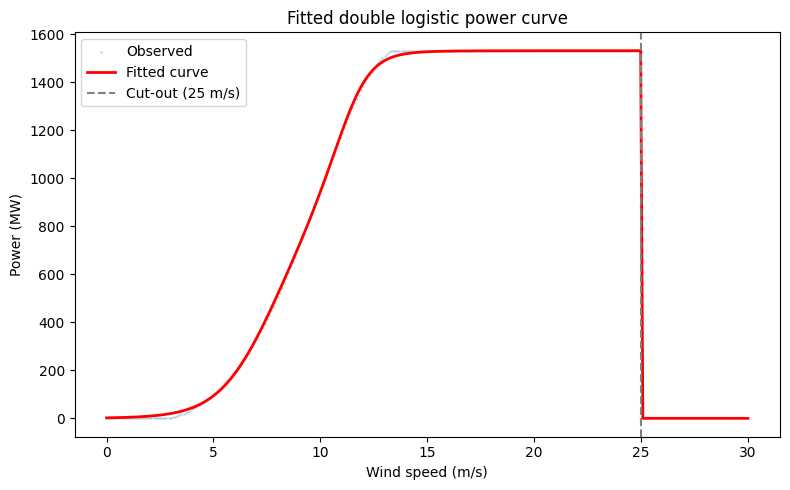

In [18]:
df = df_h_k_zuid

fit_df = df[(df["Turn_off"] == 1) & (df["Scaled_Windspeed"] > 0)].copy()

fit_df["v_bin"] = fit_df["Scaled_Windspeed"].round(1)
binned = fit_df.groupby("v_bin")["Power"].mean().reset_index()

v = binned["v_bin"].values
p = binned["Power"].values

p0 = [
    p.max(), 1.0, 0.5, 6.0,
    330, 1.0, 0.5, 11.0
]

popt, pcov = curve_fit(
    double_logistic,
    v, p,
    p0=p0,
    bounds=(
        [0, 0.01, 0, 0, 0, 0.01, 0, 0],
        [np.inf, 10, 10, 30, np.inf, 10, 10, 30]
    ),
    method='dogbox',
    maxfev=20000
)

print("Fitted parameters:")
print(f"alpha1={popt[0]:.3f}, beta1={popt[1]:.3f}, gamma1={popt[2]:.3f}, delta1={popt[3]:.3f}")
print(f"alpha2={popt[4]:.3f}, beta2={popt[5]:.3f}, gamma2={popt[6]:.3f}, delta2={popt[7]:.3f}")

results.append({
    'windfarm':   "Hollandse_Kust_Zuid",
    'alpha1': popt[0], 'beta1': popt[1],
    'gamma1': popt[2], 'delta1': popt[3],
    'alpha2': popt[4], 'beta2': popt[5],
    'gamma2': popt[6], 'delta2': popt[7],
})


# --- apply cut-out at 25 m/s ---
v_range = np.linspace(0, 30, 300)
p_fitted = np.where(
    v_range <= 25,
    double_logistic(v_range, *popt),
    0
)

# --- plot ---
plt.figure(figsize=(8, 5))
plt.scatter(v, p, s=1, alpha=0.2, label="Observed")
plt.plot(v_range, p_fitted, color="red", linewidth=2, label="Fitted curve")
plt.axvline(25, color="gray", linestyle="--", label="Cut-out (25 m/s)")
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Power (MW)")
plt.title("Fitted double logistic power curve")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
df_params = pd.DataFrame(results).set_index('windfarm')

In [115]:
def predict_power(wind_speed, popt, cut_out=25.0):
    p = double_logistic(wind_speed, *popt)
    p = np.where(wind_speed >= cut_out, 0, p)  # cut-out
    p = np.where(wind_speed < 3, 0, p)
    p = np.maximum(p, 0)
    return p

C:\Users\lackn\AppData\Local\Temp\ipykernel_23216\784927076.py:2: RuntimeWarning: overflow encountered in power
  return alpha / (1 + np.exp(-gamma * (v - delta))) ** (1 / beta)


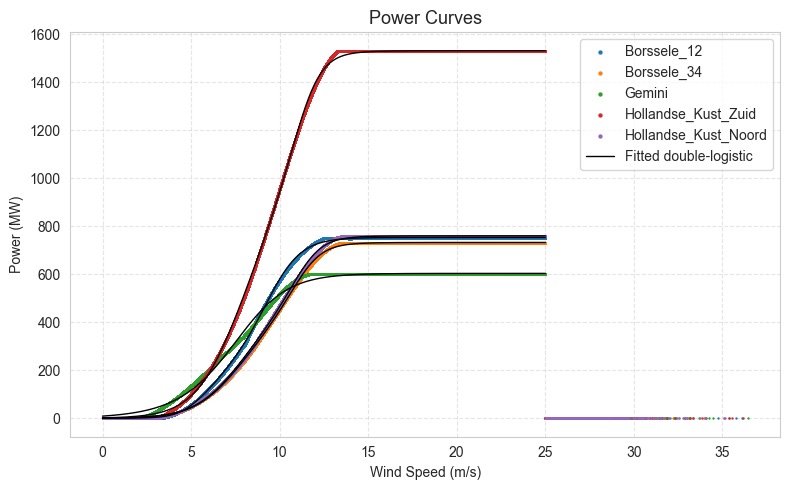

In [116]:

fig, ax = plt.subplots(figsize=(8, 5))

for label, df in datasets.items():
    ax.scatter(df['Scaled_Windspeed'], df['Power'], alpha=1, s=0.5, label=label)

# overlay fitted double-logistic curves in black
v_range = np.linspace(0, 25, 300)
for windfarm in df_params.index:
    popt = df_params.loc[windfarm].values
    fitted_power = double_logistic(v_range, *popt)
    ax.plot(v_range, fitted_power, color='black', linewidth=1)

ax.set_title('Power Curves', fontsize=13)
ax.set_xlabel('Wind Speed (m/s)')
ax.set_ylabel('Power (MW)')
# build the legend manually so the black fitted-curve line gets its own entry
handles, labels = ax.get_legend_handles_labels()
fitted_line = mlines.Line2D([], [], color='black', linewidth=1, label='Fitted double-logistic')
handles.append(fitted_line)
labels.append('Fitted double-logistic')
ax.legend(handles=handles, labels=labels, markerscale=3)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [32]:
# Save fitted parameters keyed by farm id (matching metadata_wind_farms.json 'id' field),
# so the standalone prediction module can load them without re-fitting.

cut_in_out = {
    'Borssele_12':          {"cut_in": 3.0, "cut_out": 25.0},
    'Borssele_34':          {"cut_in": 3.0, "cut_out": 25.0},
    'Gemini':               {"cut_in": 3.0, "cut_out": 25.0},
    'Hollandse_Kust_Zuid':  {"cut_in": 3.0, "cut_out": 25.0},
    'Hollandse_Kust_Noord': {"cut_in": 3.0, "cut_out": 25.0},
}

fitted_params = {
    farm_name: {
        "params": df_params.loc[farm_name, [
            'alpha1','beta1','gamma1','delta1',
            'alpha2','beta2','gamma2','delta2'
        ]].tolist(),
        "cut_in": cut_in_out[farm_name]["cut_in"],
        "cut_out": cut_in_out[farm_name]["cut_out"],
        "windspeed_linear_fit": {
            "slope": linear_fits[farm_name]["slope"],
            "intercept": linear_fits[farm_name]["intercept"],
        },
    }
    for farm_name in df_params.index
}

with open("./trained_models/knowledge_driven_model_params.json", "w") as f:
    json.dump(fitted_params, f, indent=2)

print("Saved knowledge_driven_model_params.json")

Saved knowledge_driven_model_params.json


In [22]:
# parse commissioned dates from metadata
commissioned_dates = {
    wf["id"]: pd.to_datetime(wf["commissioned"], dayfirst=True)
    for wf in wind_farms_metadata
    if "commissioned" in wf
}

df_predicted = pd.concat(
    {
        farm_name: pd.Series(
            predict_power_knowledge_model(
                station_df.loc[station_df.index >= commissioned_dates.get(farm_name, station_df.index.min()), "wind_speed_ms"].values,
                farm_name
            ),
            index=station_df.loc[station_df.index >= commissioned_dates.get(farm_name, station_df.index.min())].index
        )
        for farm_name, station_df in df_nearest_KNMI_stations.items()
    },
    axis=1, sort=True
)

df_predicted["Total"] = df_predicted.sum(axis=1)
df_predicted.index.name = "timestamp"

C:\Users\lackn\PycharmProjects\Offshore_Wind_Energy_Forecasting\models\predict_knowledge_driven_model.py:17: RuntimeWarning: overflow encountered in power
  return alpha / (1 + np.exp(-gamma * (v - delta))) ** (1 / beta)


<Axes: xlabel='timestamp'>

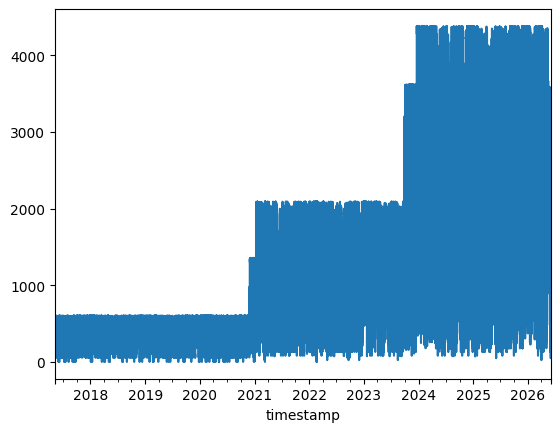

In [23]:
df_predicted["Total"].plot()

In [24]:
# Build a capacity timeline
df_farms = pd.DataFrame(wind_farms_metadata)
df_farms["commissioned"] = pd.to_datetime(df_farms["commissioned"], dayfirst=True)
df_farms["installed_capacity_mw"] = pd.to_numeric(df_farms["installed_capacity_mw"])

df_farms = df_farms.sort_values("commissioned")
df_farms["cumulative_capacity"] = df_farms["installed_capacity_mw"].cumsum()

# Sort by commission date and calculate cumulative capacity
df_farms = df_farms.sort_values("commissioned")
df_farms["cumulative_capacity"] = df_farms["installed_capacity_mw"].cumsum()


start_date = entsoe_timeseries_df.index.min()

# Filter farms commissioned before the start of the data
df_farms_filtered = df_farms[df_farms["commissioned"] >= start_date].copy()

# Recalculate cumulative capacity starting from whatever was already installed at start_date
baseline_capacity = df_farms[df_farms["commissioned"] < start_date]["installed_capacity_mw"].sum()
df_farms_filtered["cumulative_capacity"] = baseline_capacity + df_farms_filtered["installed_capacity_mw"].cumsum()

# Extend the step line
end_date = entsoe_timeseries_df.index.max()

max_capacity = df_farms_filtered["cumulative_capacity"].max()
commissioned_extended = pd.concat([pd.Series([start_date]), df_farms_filtered["commissioned"], pd.Series([end_date])])
capacity_extended = pd.concat([pd.Series([baseline_capacity]), df_farms_filtered["cumulative_capacity"], pd.Series([max_capacity])])

C:\Users\lackn\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\plotting\_matplotlib\core.py:997: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


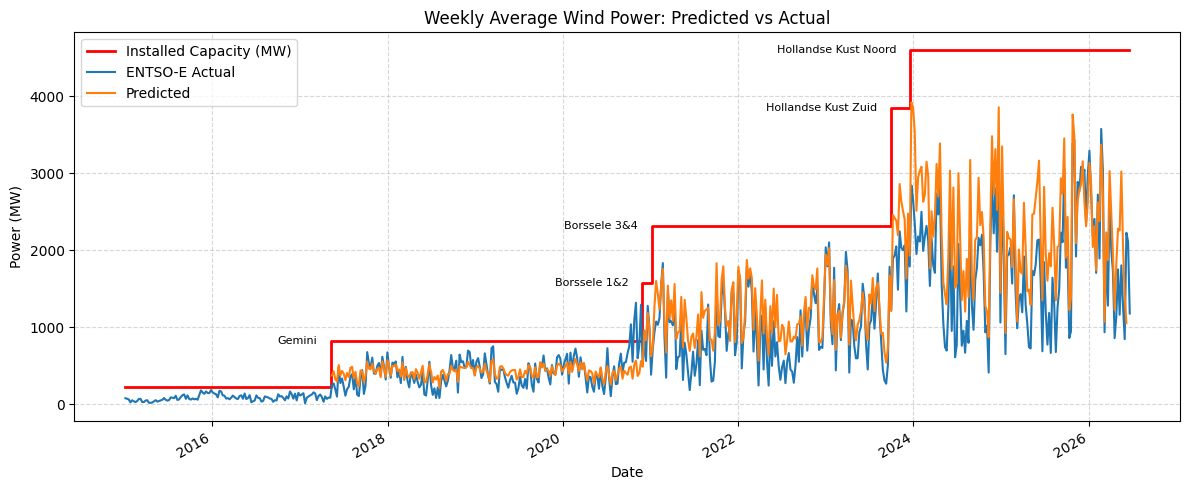

In [25]:
fig, ax = plt.subplots(figsize=(12, 5))

resample = "W"

ax.step(commissioned_extended, capacity_extended, where="post", color="red", linewidth=2, label="Installed Capacity (MW)")
entsoe_timeseries_df["Generation_MW"].resample(resample).mean().plot(ax=ax, label="ENTSO-E Actual")
df_predicted["Total"].resample(resample).mean().plot(ax=ax, label="Predicted")

for _, row in df_farms.iterrows():
    ax.annotate(row["name"],
                xy=(row["commissioned"], row["cumulative_capacity"]),
                xytext=(-10, 0),
                textcoords="offset points",
                fontsize=8,
                rotation=0,
                ha="right",
                va="center")

ax.set_title("Weekly Average Wind Power: Predicted vs Actual")
ax.set_xlabel("Date")
ax.set_ylabel("Power (MW)")
#ax.set_xlim("2026-01-01", "2026-05-31")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

C:\Users\lackn\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\plotting\_matplotlib\core.py:997: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


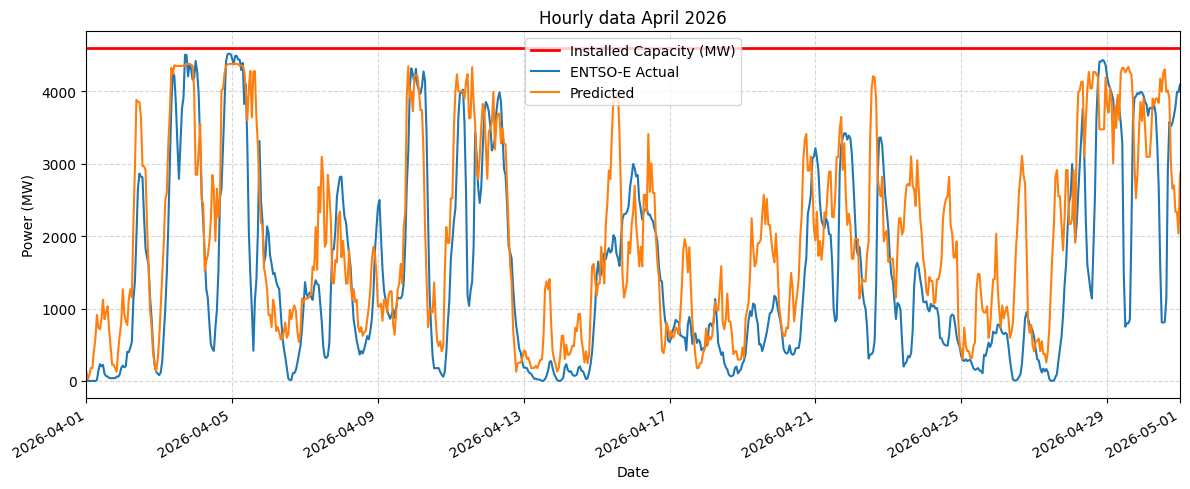

In [26]:
fig, ax = plt.subplots(figsize=(12, 5))

resample = "h"

ax.step(commissioned_extended, capacity_extended, where="post", color="red", linewidth=2, label="Installed Capacity (MW)")
entsoe_timeseries_df["Generation_MW"].resample(resample).mean().plot(ax=ax, label="ENTSO-E Actual")
df_predicted["Total"].resample(resample).mean().plot(ax=ax, label="Predicted")

for _, row in df_farms.iterrows():
    ax.annotate(row["name"],
                xy=(row["commissioned"], row["cumulative_capacity"]),
                xytext=(-10, 0),
                textcoords="offset points",
                fontsize=8,
                rotation=0,
                ha="right",
                va="center")

ax.set_title("Hourly data April 2026")
ax.set_xlabel("Date")
ax.set_ylabel("Power (MW)")
ax.set_xlim("2026-04-01", "2026-05-01")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [27]:
def evaluate_predictions(actual, predicted):
    mask = actual.notna() & predicted.notna()
    actual_clean = actual[mask]
    predicted_clean = predicted[mask]

    mae = mean_absolute_error(actual_clean, predicted_clean)
    rmse = np.sqrt(mean_squared_error(actual_clean, predicted_clean))
    r2 = r2_score(actual_clean, predicted_clean)

    return {"mae": mae, "rmse": rmse, "r2": r2, "n": mask.sum()}


print("=== HOURLY ===\n")

per_farm_results_hourly = {}
for farm_name in datasets.keys():
    actual_power = datasets[farm_name]["Power"]
    predicted_power = df_predicted[farm_name]

    aligned = pd.concat(
        {"actual": actual_power, "predicted": predicted_power},
        axis=1, join="inner"
    ).dropna()

    if len(aligned) == 0:
        print(f"{farm_name}: no overlapping timestamps, skipping")
        continue

    result = evaluate_predictions(aligned["actual"], aligned["predicted"])
    per_farm_results_hourly[farm_name] = result
    print(f"{farm_name}: MAE={result['mae']:.2f} MW, RMSE={result['rmse']:.2f} MW, "
          f"R²={result['r2']:.3f}, n={result['n']}")

aligned_total_hourly = pd.concat(
    {"actual": entsoe_timeseries_df["Generation_MW"], "predicted": df_predicted["Total"]},
    axis=1, join="inner"
).dropna()
total_result_hourly = evaluate_predictions(aligned_total_hourly["actual"], aligned_total_hourly["predicted"])
print(f"\nTOTAL (vs ENTSOE): MAE={total_result_hourly['mae']:.2f} MW, "
      f"RMSE={total_result_hourly['rmse']:.2f} MW, R²={total_result_hourly['r2']:.3f}, n={total_result_hourly['n']}")


print("\n=== DAILY (resampled mean) ===\n")

per_farm_results_daily = {}
for farm_name in datasets.keys():
    actual_power = datasets[farm_name]["Power"].resample("D").mean()
    predicted_power = df_predicted[farm_name].resample("D").mean()

    aligned = pd.concat(
        {"actual": actual_power, "predicted": predicted_power},
        axis=1, join="inner"
    ).dropna()

    if len(aligned) == 0:
        print(f"{farm_name}: no overlapping timestamps, skipping")
        continue

    result = evaluate_predictions(aligned["actual"], aligned["predicted"])
    per_farm_results_daily[farm_name] = result
    print(f"{farm_name}: MAE={result['mae']:.2f} MW, RMSE={result['rmse']:.2f} MW, "
          f"R²={result['r2']:.3f}, n={result['n']}")

aligned_total_daily = pd.concat(
    {"actual": entsoe_timeseries_df["Generation_MW"].resample("D").mean(),
     "predicted": df_predicted["Total"].resample("D").mean()},
    axis=1, join="inner"
).dropna()
total_result_daily = evaluate_predictions(aligned_total_daily["actual"], aligned_total_daily["predicted"])
print(f"\nTOTAL (vs ENTSOE): MAE={total_result_daily['mae']:.2f} MW, "
      f"RMSE={total_result_daily['rmse']:.2f} MW, R²={total_result_daily['r2']:.3f}, n={total_result_daily['n']}")

=== HOURLY ===

Borssele_12: no overlapping timestamps, skipping
Borssele_34: no overlapping timestamps, skipping
Gemini: MAE=95.58 MW, RMSE=139.92 MW, R²=0.519, n=23232
Hollandse_Kust_Zuid: no overlapping timestamps, skipping
Hollandse_Kust_Noord: no overlapping timestamps, skipping

TOTAL (vs ENTSOE): MAE=402.05 MW, RMSE=588.79 MW, R²=0.677, n=79512

=== DAILY (resampled mean) ===

Borssele_12: no overlapping timestamps, skipping
Borssele_34: no overlapping timestamps, skipping
Gemini: MAE=63.34 MW, RMSE=84.24 MW, R²=0.751, n=968
Hollandse_Kust_Zuid: no overlapping timestamps, skipping
Hollandse_Kust_Noord: no overlapping timestamps, skipping

TOTAL (vs ENTSOE): MAE=319.58 MW, RMSE=433.59 MW, R²=0.786, n=3313


In [31]:
df_predicted_full = pd.concat(
    {
        farm_name: pd.Series(
            predict_power_knowledge_model(
                station_df["wind_speed_ms"].values,
                farm_name
            ),
            index=station_df.index
        )
        for farm_name, station_df in df_nearest_KNMI_stations.items()
    },
    axis=1, sort=True
)
df_predicted_full.index.name = "timestamp"


# --- metrics against each farm's offshore Power column ---

def evaluate_predictions(actual, predicted):
    mask = actual.notna() & predicted.notna()
    actual_clean = actual[mask]
    predicted_clean = predicted[mask]

    mae = mean_absolute_error(actual_clean, predicted_clean)
    rmse = np.sqrt(mean_squared_error(actual_clean, predicted_clean))
    r2 = r2_score(actual_clean, predicted_clean)

    return {"mae": mae, "rmse": rmse, "r2": r2, "n": mask.sum()}


results = []

for farm_name, farm_df in datasets.items():
    actual_power = farm_df["Power"]
    predicted_power = df_predicted_full[farm_name]

    aligned = pd.concat(
        {"actual": actual_power, "predicted": predicted_power},
        axis=1, join="inner"
    ).dropna()

    if len(aligned) == 0:
        print(f"{farm_name}: no overlapping timestamps, skipping")
        continue

    result = evaluate_predictions(aligned["actual"], aligned["predicted"])
    results.append({"farm": farm_name, **result})

    print(f"{farm_name}: MAE={result['mae']:.2f} MW, RMSE={result['rmse']:.2f} MW, "
          f"R²={result['r2']:.3f}, n={result['n']}")

metrics_df = pd.DataFrame(results)
metrics_df.columns = ["Farm", "MAE (MW)", "RMSE (MW)", "R²", "n"]
metrics_df = metrics_df.round({"MAE (MW)": 2, "RMSE (MW)": 2, "R²": 3})

metrics_df



Borssele_12: MAE=126.13 MW, RMSE=183.79 MW, R²=0.591, n=43824
Borssele_34: MAE=125.01 MW, RMSE=176.65 MW, R²=0.575, n=43824
Gemini: MAE=93.70 MW, RMSE=137.96 MW, R²=0.538, n=43824
Hollandse_Kust_Zuid: MAE=222.28 MW, RMSE=321.32 MW, R²=0.680, n=43824
Hollandse_Kust_Noord: MAE=131.77 MW, RMSE=188.22 MW, R²=0.562, n=43824


C:\Users\lackn\PycharmProjects\Offshore_Wind_Energy_Forecasting\models\predict_knowledge_driven_model.py:17: RuntimeWarning: overflow encountered in power
  return alpha / (1 + np.exp(-gamma * (v - delta))) ** (1 / beta)


,Farm,MAE (MW),RMSE (MW),R²,n
0,Borssele_12,126.13,183.79,0.591,43824
1,Borssele_34,125.01,176.65,0.575,43824
2,Gemini,93.70,137.96,0.538,43824
3,Hollandse_Kust_Zuid,222.28,321.32,0.680,43824
4,Hollandse_Kust_Noord,131.77,188.22,0.562,43824


In [30]:
results = []
print("Hourly")
for farm_name, farm_df in datasets.items():
    actual_power = farm_df["Power"]
    predicted_power = df_predicted_full[farm_name]

    aligned = pd.concat(
        {"actual": actual_power, "predicted": predicted_power},
        axis=1, join="inner"
    ).dropna()

    if len(aligned) == 0:
        print(f"{farm_name}: no overlapping timestamps, skipping")
        continue

    result = evaluate_predictions(aligned["actual"], aligned["predicted"])
    results.append({"farm": farm_name, **result})

    print(f"{farm_name}: MAE={result['mae']:.2f} MW, RMSE={result['rmse']:.2f} MW, "
          f"R²={result['r2']:.3f}, n={result['n']}")

metrics_df = pd.DataFrame(results)
metrics_df.columns = ["Farm", "MAE (MW)", "RMSE (MW)", "R²", "n"]
metrics_df = metrics_df.round({"MAE (MW)": 2, "RMSE (MW)": 2, "R²": 3})

# --- Daily metrics ---
results_daily = []
print("Daily")
for farm_name, farm_df in datasets.items():
    actual_power = farm_df["Power"]
    predicted_power = df_predicted_full[farm_name]

    aligned = pd.concat(
        {"actual": actual_power, "predicted": predicted_power},
        axis=1, join="inner"
    ).dropna().resample("D").mean().dropna()

    if len(aligned) == 0:
        print(f"{farm_name}: no overlapping timestamps, skipping")
        continue

    result = evaluate_predictions(aligned["actual"], aligned["predicted"])
    results_daily.append({"farm": farm_name, **result})

    print(f"{farm_name}: MAE={result['mae']:.2f} MW, RMSE={result['rmse']:.2f} MW, "
          f"R²={result['r2']:.3f}, n={result['n']}")

metrics_daily_df = pd.DataFrame(results_daily)
metrics_daily_df.columns = ["Farm", "MAE (MW)", "RMSE (MW)", "R²", "n"]
metrics_daily_df = metrics_daily_df.round({"MAE (MW)": 2, "RMSE (MW)": 2, "R²": 3})

Borssele_12: MAE=126.13 MW, RMSE=183.79 MW, R²=0.591, n=43824
Borssele_34: MAE=125.01 MW, RMSE=176.65 MW, R²=0.575, n=43824
Gemini: MAE=93.70 MW, RMSE=137.96 MW, R²=0.538, n=43824
Hollandse_Kust_Zuid: MAE=222.28 MW, RMSE=321.32 MW, R²=0.680, n=43824
Hollandse_Kust_Noord: MAE=131.77 MW, RMSE=188.22 MW, R²=0.562, n=43824
Borssele_12: MAE=78.69 MW, RMSE=103.75 MW, R²=0.815, n=1826
Borssele_34: MAE=80.59 MW, RMSE=105.04 MW, R²=0.791, n=1826
Gemini: MAE=63.07 MW, RMSE=84.04 MW, R²=0.757, n=1826
Hollandse_Kust_Zuid: MAE=147.88 MW, RMSE=194.44 MW, R²=0.839, n=1826
Hollandse_Kust_Noord: MAE=92.02 MW, RMSE=121.51 MW, R²=0.748, n=1826


In [96]:
"""
#single logistic fit
def single_logistic(v, alpha, beta, gamma, delta):
    return alpha / (1 + np.exp(-gamma * (v - delta))) ** (1 / beta)

def predict_power(wind_speed, popt, cut_in=3.0, cut_out=25.0):
    p = single_logistic(wind_speed, *popt)
    return p

# --- prep data ---
fit_df = df[(df["Turn_off"] == 1)].copy()

v = fit_df["Scaled_Windspeed"].values
p = fit_df["Power"].values

# --- fit ---
p0 = [
    p.max(),  # alpha: rated power
    1.0,      # beta
    1.0,      # gamma: steepness
    10.0      # delta: inflection point
]

popt, pcov = curve_fit(
    single_logistic,
    v, p,
    p0=p0,
    bounds=(
        [0,    0.01, 0,    0  ],
        [p.max()*1, 10,   10,   30]
    ),
    maxfev=10000
)

print("Fitted parameters:")
print(f"alpha={popt[0]:.3f}, beta={popt[1]:.3f}, gamma={popt[2]:.3f}, delta={popt[3]:.3f}")

# --- plot ---
v_range = np.linspace(0, 35, 500)
p_fitted = predict_power(v_range, popt)

plt.figure(figsize=(8, 5))
plt.scatter(v, p, s=1, alpha=0.2, label="Observed")
plt.plot(v_range, p_fitted, color="red", linewidth=2, label="Fitted curve")
plt.axvline(25, color="gray", linestyle="--", label="Cut-out (25 m/s)")
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Power (MW)")
plt.title("Fitted single logistic power curve")
plt.legend()
plt.tight_layout()
plt.show()
"""

'\n#single logistic fit\ndef single_logistic(v, alpha, beta, gamma, delta):\n    return alpha / (1 + np.exp(-gamma * (v - delta))) ** (1 / beta)\n\ndef predict_power(wind_speed, popt, cut_in=3.0, cut_out=25.0):\n    p = single_logistic(wind_speed, *popt)\n    return p\n\n# --- prep data ---\nfit_df = df[(df["Turn_off"] == 1)].copy()\n\nv = fit_df["Scaled_Windspeed"].values\np = fit_df["Power"].values\n\n# --- fit ---\np0 = [\n    p.max(),  # alpha: rated power\n    1.0,      # beta\n    1.0,      # gamma: steepness\n    10.0      # delta: inflection point\n]\n\npopt, pcov = curve_fit(\n    single_logistic,\n    v, p,\n    p0=p0,\n    bounds=(\n        [0,    0.01, 0,    0  ],\n        [p.max()*1, 10,   10,   30]\n    ),\n    maxfev=10000\n)\n\nprint("Fitted parameters:")\nprint(f"alpha={popt[0]:.3f}, beta={popt[1]:.3f}, gamma={popt[2]:.3f}, delta={popt[3]:.3f}")\n\n# --- plot ---\nv_range = np.linspace(0, 35, 500)\np_fitted = predict_power(v_range, popt)\n\nplt.figure(figsize=(8, 5))\n

In [97]:
# --- prep data ---
fit_df = df[(df["Turn_off"] == 1) & (df["Scaled_Windspeed"] > 0)].copy()

# bin by wind speed
fit_df["v_bin"] = fit_df["Scaled_Windspeed"].round(1)
binned = fit_df.groupby("v_bin")["Power"].mean().reset_index()

# --- cut-in: lowest wind speed where power becomes non-zero ---
cut_in_speed = binned.loc[binned["Power"] > 1, "v_bin"].min()

# --- rated: lowest wind speed where power reaches max and stays there ---
p_max = binned["Power"].max()
rated_speed = binned.loc[binned["Power"] >= 0.99 * p_max, "v_bin"].min()

print(f"Cut-in wind speed: {cut_in_speed:.2f} m/s")
print(f"Rated wind speed: {rated_speed:.2f} m/s")
print(f"Max observed power: {p_max:.2f} MW")

Cut-in wind speed: 3.10 m/s
Rated wind speed: 13.20 m/s
Max observed power: 759.00 MW


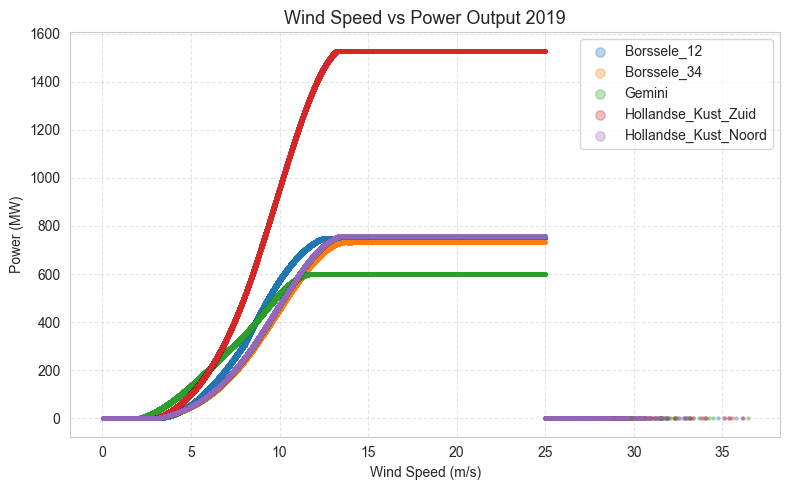

In [98]:
fig, ax = plt.subplots(figsize=(8, 5))

for label, df in datasets.items():
    ax.scatter(df['Scaled_Windspeed'], df['Power'], alpha=0.3, s=5, label=label)

ax.set_title('Wind Speed vs Power Output 2019', fontsize=13)
ax.set_xlabel('Wind Speed (m/s)')
ax.set_ylabel('Power (MW)')
ax.legend(markerscale=3)   # markerscale makes the tiny dots visible in the legend
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()